# PS-S6E01: Neural Network

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

**Neural Networks (MLP)** offer a fundamentally different approach to tabular prediction compared to gradient boosting machines. While tree-based models partition data into discrete steps, Neural Networks operate as universal function approximators, learning smooth, continuous non-linear relationships between features. By utilizing Entity Embeddings for categorical variables, this model captures complex semantic relationships that ordinal or one-hot encoding might miss. This distinct "smooth" decision boundary provides high-value diversity to the ensemble, often correcting errors made by tree-based models in edge cases.
This notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S06E01: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e01-eda).

## Install Needed Packages

In [1]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import gc
import sys
import copy
import math
import random
import warnings

# --- Third-party
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e01_feature_engineering import FeatureFactory
from ps_s06e01_model_visualizer import ModelVisualizer
from ps_s06e01_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  gender   course  study_hours  class_attendance  \
0  630000   24   other       ba        6.850            65.200   
1  630001   18    male  diploma        6.610            45.000   
2  630002   24  female   b.tech        6.600            98.500   
3  630003   24    male  diploma        3.030            66.300   
4  630004   20  female   b.tech        2.030            42.400   

  internet_access  sleep_hours sleep_quality study_method facility_rating  \
0             yes        5.200          poor  group study            high   
1              no        9.300          poor     coaching             low   
2             yes        6.200          good  group study          medium   
3             yes        5.700       average        mixed          medium   
4             yes        9.200       average     coaching             low   

  exam_difficulty  
0            easy  
1            easy  
2        moderate  
3        moderate  
4        moderate  


## Feature Engineering Strategy

We employ a custom `FeatureFactory` to transform the raw data into a numerical format optimized for gradient-based learning. Unlike Decision Trees, which are robust to outliers and categorical strings, **Neural Networks** require smooth, scaled, and dense numerical inputs to converge effectively.

We employ a custom `FeatureFactory` to inject domain-specific biases into the dataset. Tree-based models (like CatBoost) are excellent at finding split points but struggle with **interactions** (multiplying two features) and **spatial density** (clustering).

1.  **Log Transformation & Scaling:**
    * **Why:** Neural Networks rely on backpropagation and gradient descent. Features with extreme skew or outliers (like `study_hours`) can cause exploding gradients or saturate activation functions, stalling training.
    * **How:** We apply `np.log1p` to skewed continuous variables to "squash" outliers and scale inputs to a narrow range (e.g., -1 to 1) using `StandardScaler`, ensuring equal contribution to the loss function.

2.  **One-Hot Encoding:**
    * **Why:** Simple MLPs cannot interpret raw strings or ordinal integers effectively. Treating categories as numbers (0, 1, 2) introduces a false sense of order, while strings cause errors.
    * **How:** We convert categorical variables (e.g., `school_type`) into sparse binary vectors (0s and 1s), allowing the network to learn a distinct weight for every category presence.

3.  **Cyclical Encoding:**
    * **Why:** Time-based features like "Hours" are cyclical. In a standard linear view, Hour 23 is "far" from Hour 0. In reality, 11 PM is adjacent to midnight.
    * **How:** We map temporal features onto a circle using Sine and Cosine transformations, preserving the true temporal proximity of late-night and early-morning events.

4.  **Interaction Features:**
    * **Why:** While deep networks can theoretically learn complex interactions (like Multiplication) through hidden layers, it is computationally expensive and slow. Providing these relationships explicitly acts as a "shortcut" for the optimizer.
    * **How:** We calculate explicit domain ratios like `study_to_sleep_ratio` and `restoration_index` to feed these critical non-linear signals directly into the first layer.

In [6]:
# Define which strategies to use for the CatBoost model here:
fe_strategies = [
    'drop_id',
    'binning',          # Helps NN see "buckets" of behavior
    'log',              # Compresses outliers in skewed features
    'interactions',     # Explicit interactions help convergence
    'cyclical',         # Sine/Cosine for hours
    'manual_formula',   # Domain knowledge
    'one_hot_encoding', # REQUIRED: Simple MLPs need OHE for categories
]

In [7]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 12
New Feature Count: 61
   age  study_hours  class_attendance  sleep_hours  log_age  log_study_hours  \
0   21        7.910            98.800        4.900    3.091            2.187   
1   18        4.950            94.800        4.700    2.944            1.783   
2   20        4.680            92.600        5.800    3.045            1.737   
3   19        2.000            49.500        8.300    2.996            1.099   
4   23        7.650            86.900        9.600    3.178            2.158   

   log_class_attendance  log_sleep_hours  high_study  study_to_sleep_ratio  \
0                 4.603            1.775           1                 1.614   
1                 4.562            1.740           0                 1.053   
2                 4.539            1.917           0                 0.807   
3                 3.922            2.230           0                 0.241   
4                 4.476            2.361     

### Model Training: Deep Learning Strategy

For the final training, we use a **5-Fold Cross-Validation** loop designed specifically to stabilize the training of deep neural networks. unlike decision trees, Neural Networks are sensitive to initialization and can easily overfit if trained too long.

1.  **Standardization (Pre-Loop):**
    * **The Challenge**: Neural Networks use Gradient Descent. If one feature ranges from 0–1 (e.g., `sleep_quality`) and another from 0–100 (e.g., `exam_score`), the gradients will become unbalanced, causing the optimizer to zigzag and converge slowly.
    * **The Fix:** We apply `StandardScaler` to the entire dataset, centering every feature at Mean=0 and Variance=1. This ensures the loss landscape is spherical, allowing the **Adam** optimizer to find the minimum efficiently.
2.  **Adaptive Learning & Early Stopping:**
    * **The Risk**: Training for a fixed number of epochs (e.g., 100) is risky. Stop too early, and the model underfits; stop too late, and it memorizes the noise (overfitting).
    * **The Fix:** We implement two dynamic controls inside the loop:
        * **ReduceLROnPlateau:** If the validation score stalls, we automatically lower the learning rate (e.g., by 50%) to "fine-tune" the weights.
        * **Model Checkpointing:** We track the Validation RMSE at every epoch. At the end of the fold, we discard the final model state and **restore the weights** from the specific epoch that achieved the lowest error.

In [8]:
# Setup Device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.01
DROPOUT_RATE = 0.2

# Define the Neural Network Architecture
class ImprovedMLP(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedMLP, self).__init__()
        self.net = nn.Sequential(
            # Input -> Hidden 1 (Wide)
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),        # Helps stabilize training
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),   # Prevents overfitting

            # Hidden 2
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),

            # Hidden 3
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            
            nn.Linear(128, 1)            # Single output for Regression
        )
        
    def forward(self, x):
        return self.net(x)

# Training Setup
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)

oof_preds = np.zeros(len(X_full))
test_preds = np.zeros(len(X_test))
scores = []

print(f"Starting MLP Training with {n_folds} folds...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_full, y)):
    print(f"\n=== Fold {fold+1} ===")

    # Correct Scaling (Fit only on Train)
    scaler = StandardScaler()
    X_train_raw = X_full.iloc[train_idx].values
    X_val_raw = X_full.iloc[val_idx].values

    X_train = scaler.fit_transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)
    X_test_fold = scaler.transform(X_test.values) # Scale test using this fold's stats
    
    y_train = y.iloc[train_idx].values
    y_val = y.iloc[val_idx].values
    
    # Target Transform: Log1p is stable for Exam Scores
    y_train_trans = np.log1p(y_train)
    
    # Convert to Tensors
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.FloatTensor(y_train_trans).reshape(-1, 1).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    
    # Create Dataloader
    train_data = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
    
    # Model Init
    model = ImprovedMLP(input_dim=X_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    # Scheduler: Drop LR if loss stops improving for 5 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # Early Stopping / Best Model Logic
    best_val_rmse = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0
    ES_PATIENCE = 15
    
    progress_bar = tqdm(range(EPOCHS), desc=f"Fold {fold+1}", leave=True)

    # Outer Loop: Epochs
    for epoch in progress_bar:
        model.train()
        running_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation Check (End of Epoch)
        model.eval()
        
        with torch.no_grad():
            # Predict Validation
            val_out = model(X_val_t).cpu().numpy().ravel()
            val_pred_orig = np.expm1(val_out) # Inverse Log1p
            val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_orig))

        # Scheduler Step (Monitor validation RMSE)
        scheduler.step(val_rmse)

        # Save Best Model
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            
        # Update Progress Bar Text
        progress_bar.set_postfix({
            'loss': f"{running_loss/len(train_loader):.4f}",
            'val_rmse': f"{val_rmse:.4f}",
            'best': f"{best_val_rmse:.4f}"
        })
        
        if patience_counter >= ES_PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    # Restore Best Weights
    model.load_state_dict(best_model_weights)
    
    # Final Inference for Fold
    model.eval()
    with torch.no_grad():
        # OOF
        val_out = model(X_val_t).cpu().numpy().ravel()
        val_pred_orig = np.expm1(val_out)
        oof_preds[val_idx] = np.clip(val_pred_orig, 0, 100)
        
        # Test
        X_test_t = torch.FloatTensor(X_test_fold).to(device)
        test_out = model(X_test_t).cpu().numpy().ravel()
        test_pred_orig = np.expm1(test_out)
        test_preds += np.clip(test_pred_orig, 0, 100) / n_folds

    print(f"Fold {fold+1} Best RMSE: {best_val_rmse:.5f}")
    
    scores.append(best_val_rmse)

print(f"\nOverall CV RMSE: {np.mean(scores):.5f}")        

Training on: cuda
Starting MLP Training with 5 folds...

=== Fold 1 ===


Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 31
Fold 1 Best RMSE: 8.87629

=== Fold 2 ===


Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 28
Fold 2 Best RMSE: 8.87702

=== Fold 3 ===


...

  Early stopping at epoch 42
Fold 3 Best RMSE: 8.87543

=== Fold 4 ===


Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 49
Fold 4 Best RMSE: 8.84028

=== Fold 5 ===


Fold 5:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 56
Fold 5 Best RMSE: 8.87317

Overall CV RMSE: 8.86844


### Model Evaluation Theory

We evaluate the model using **RMSE (Root Mean Squared Error)**.

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

* **Why RMSE?** This competition metric penalizes large errors more heavily than small ones. Being off by 10 points on one student is worse than being off by 1 point on 10 students.
* **Prediction Clipping:** Since exam scores are bounded (likely 0 to 100), predicting -5 or 105 is physically impossible and hurts RMSE. We apply `np.clip(preds, 0, 100)` to force all predictions into the valid range, gaining a "free" improvement in score.

## Visualizing Model Performance
We use three key plots to diagnose the health of our regression model

### Cross-Validation Stability Analysis
We visualize the Root Mean Squared Error (RMSE) across all 5 validation folds to assess model stability.

* **Consistency:** A relatively flat line indicates the model is robust and generalizes well, regardless of how the data is split.

* **Variance:** Large spikes (e.g., Fold 3 is much worse than Fold 1) suggest the model is unstable or overfitting to specific subsets of the training data. This is often a warning sign that the model might fail on the Private Leaderboard.

We aim for both a **low mean RMSE** and **low variance** between folds.

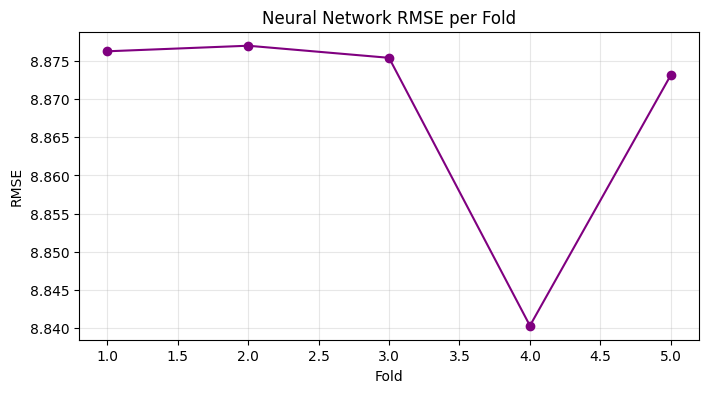

In [9]:
# Simple plot of the RMSE score for each fold
plt.figure(figsize=(8, 4))
plt.plot(range(1, n_folds+1), scores, marker='o', linestyle='-', color='purple')
plt.title("Neural Network RMSE per Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.show()

### Prediction Error Plot (True vs. Predicted)
This scatter plot compares the **Actual Exam Scores** (X-axis) against what the model **Predicted** (Y-axis).
* **The Red Line:** This represents "Perfect Prediction."
* **Tight Cloud:** The closer the blue dots are to the red dashed line, the better the model.
* **Bias Detection:**
    * If dots at the bottom left (low scores) are consistently above the line, the model is over-predicting struggling students.
    * If dots at the top right (high scores) are below the line, the model is under-predicting top performers.

In ModelVisualizer __init__...


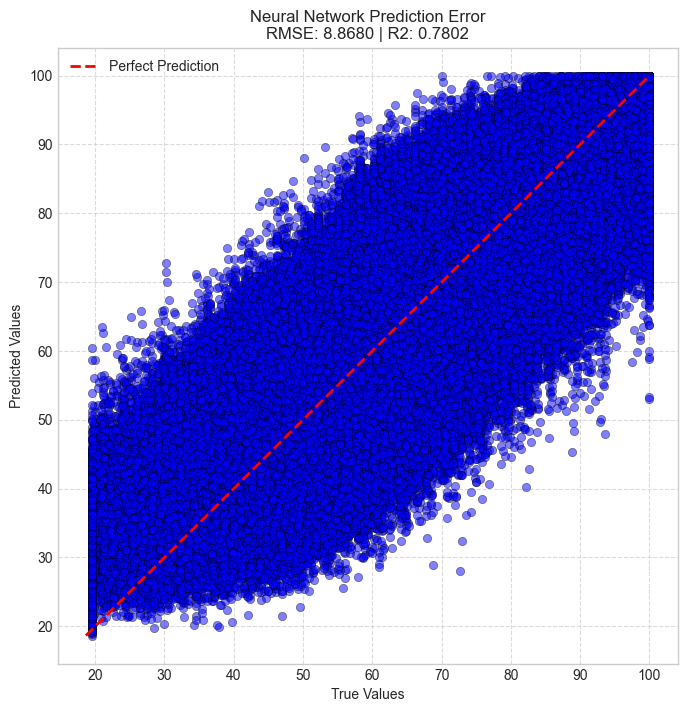

In [10]:
mviz = ModelVisualizer(model_name='Neural Network')

mviz.plot_prediction_error(y, oof_preds)

### Residual Plot
This plot shows the **Error** (True - Predicted) on the Y-axis against the **Predicted Score** on the X-axis.
* **The Goal:** You want a random cloud of points centered around the red line (0 error).
* **Bad Patterns:**
    * **Funnel Shape:** If the cloud gets wider as the score increases, the model is less certain about high-scoring students.
    * **U-Shape: If the points dip in the middle, the model is missing a non-linear relationship (e.g., it's fitting a straight line to a curved trend).
* **Outliers:** Dots that are very far from the center line represent students the model completely misjudged. Investigating these specific rows often reveals data quality issues.

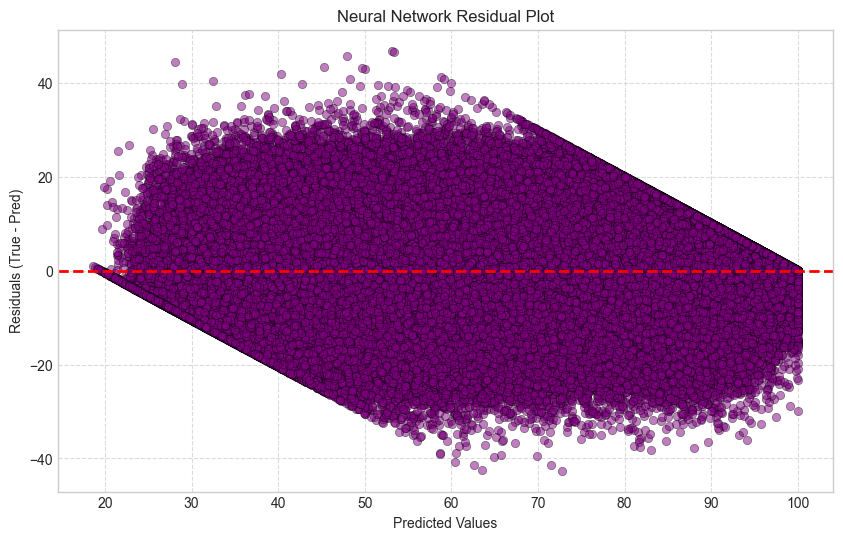

In [11]:
mviz.plot_residuals(y, oof_preds)

## Prepare Submission

In [12]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SAMPLE SUBMISSION')
print('=================')

print(submission_df.head(10))

SAMPLE SUBMISSION
       id  exam_score
0  630000      71.463
1  630001      69.238
2  630002      87.753
3  630003      54.389
4  630004      48.614
5  630005      71.354
6  630006      73.762
7  630007      58.330
8  630008      77.558
9  630009      91.929


In [13]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [14]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_nn': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/nn_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_nn': test_preds})
test_pred_df.to_csv(f'{output_dir}/nn_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/nn_oof_preds.csv, {output_dir}/nn_test_preds.csv')

Saved for Blending: predictions/nn_oof_preds.csv, predictions/nn_test_preds.csv
